# Project Presentation

This notebook focuses on forecasting the UV Index using historical UV data combined with meteorological and atmospheric variables (e.g., cloud cover, ozone, aerosols, temperature). In addition to prediction, the analysis explores correlations between UV exposure and health-related risks to support risk categorization and preventive insights.

# Loading

## Libraries

### General

In [1]:
# Standard library
import ast
import csv
import os
import pickle
import re
import sys
import traceback
import warnings
from datetime import datetime
from pathlib import Path
from urllib.parse import parse_qs, urlencode, urlparse, urlunparse

# Third-party: scientific & data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats
import seaborn as sns

### Models

In [2]:
from sklearn.ensemble import (
AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Third-party: gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Third-party: deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, GRU, LSTM
from tensorflow.keras.models import Sequential

In [3]:
import preprocess
import plot
import ts
import ml
import dl
import boosters

## Data

In [4]:
algeria_df = pd.read_csv('data/UV-ALGERIA.csv')

# EDA

### General View

In [5]:
print("Data Info:")
algeria_df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16376 entries, 0 to 16375
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 16376 non-null  object 
 1   T2M                  16376 non-null  float64
 2   T2MDEW               16376 non-null  float64
 3   T2MWET               16376 non-null  float64
 4   TS                   16376 non-null  float64
 5   T2M_RANGE            16376 non-null  float64
 6   T2M_MAX              16376 non-null  float64
 7   T2M_MIN              16376 non-null  float64
 8   RH2M                 16376 non-null  float64
 9   PRECTOTCORR          16376 non-null  float64
 10  WS2M                 16376 non-null  float64
 11  WD2M                 16376 non-null  float64
 12  WS10M                16376 non-null  float64
 13  WD10M                16376 non-null  float64
 14  WS50M                16376 non-null  float64
 15  WD50M                1637

In [6]:
print("\nDescriptive Statistics:")
print(algeria_df.describe())


Descriptive Statistics:
                T2M        T2MDEW        T2MWET            TS     T2M_RANGE  \
count  16376.000000  16376.000000  16376.000000  16376.000000  16376.000000   
mean      19.064826     14.330520     16.697673     19.366862      3.131197   
std        4.811496      4.586648      4.628936      4.564072      1.156296   
min        6.260000      0.490000      4.160000     11.720000      0.310000   
25%       14.910000     10.690000     12.840000     15.170000      2.340000   
50%       18.380000     14.025000     16.170000     18.530000      3.010000   
75%       23.480000     18.360000     20.910000     23.620000      3.750000   
max       32.270000     24.680000     26.300000     30.410000     11.050000   

            T2M_MAX       T2M_MIN          RH2M   PRECTOTCORR          WS2M  \
count  16376.000000  16376.000000  16376.000000  16376.000000  16376.000000   
mean      20.707490     17.576293     75.050748      1.517882      4.093137   
std        5.047768      4


Correlation Matrix:


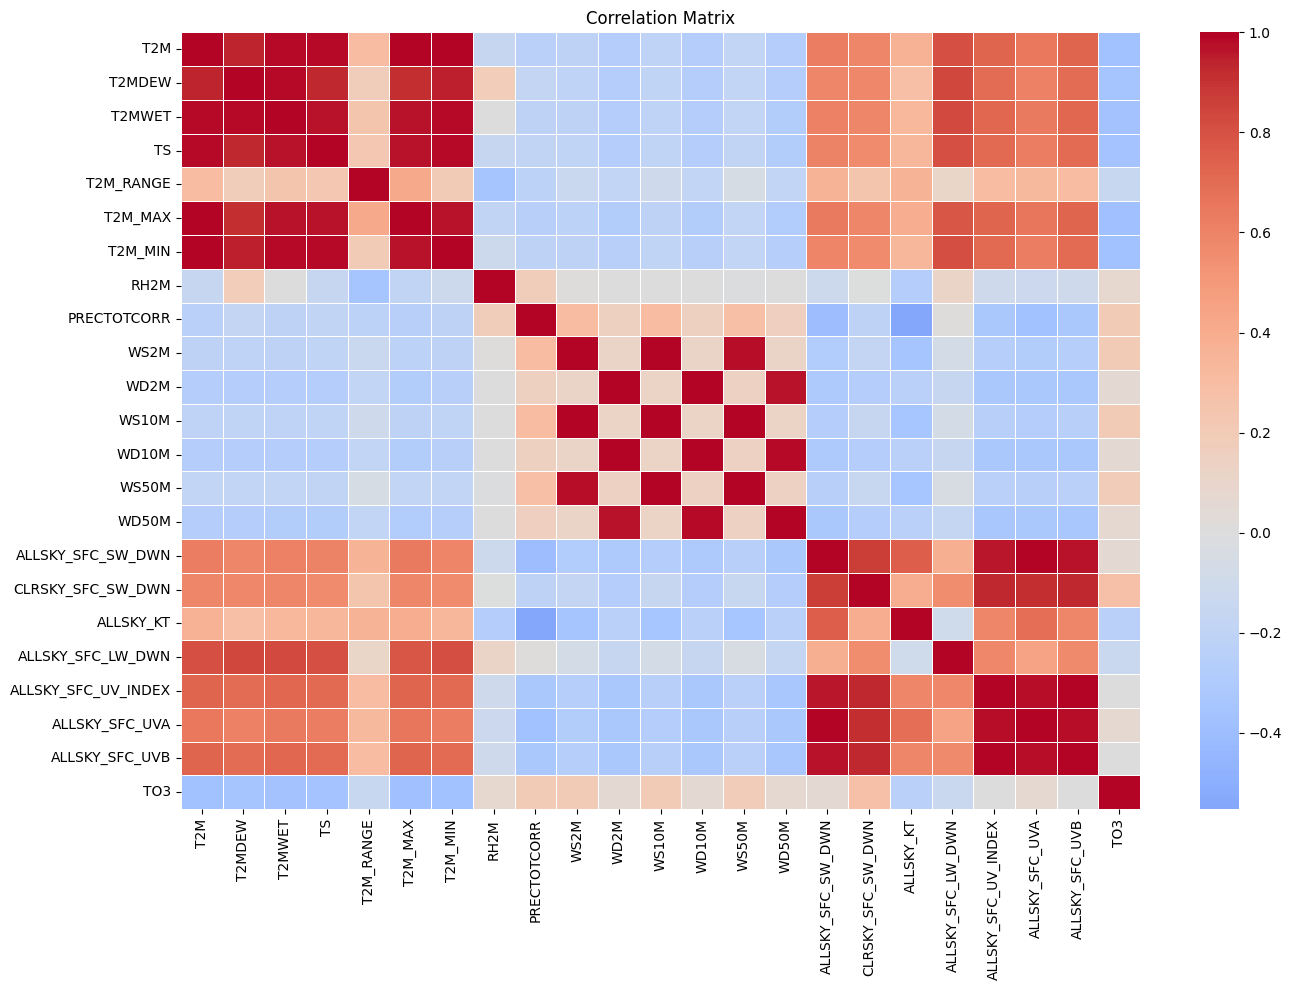

In [7]:
print("\nCorrelation Matrix:")
corr = algeria_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [8]:
print("Null counts per column:")
print(algeria_df.isnull().sum())

Null counts per column:
Date                      0
T2M                       0
T2MDEW                    0
T2MWET                    0
TS                        0
T2M_RANGE                 0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
PRECTOTCORR               0
WS2M                      0
WD2M                      0
WS10M                     0
WD10M                     0
WS50M                     0
WD50M                     0
ALLSKY_SFC_SW_DWN      1095
CLRSKY_SFC_SW_DWN      1118
ALLSKY_KT              7338
ALLSKY_SFC_LW_DWN      2556
ALLSKY_SFC_UV_INDEX    7338
ALLSKY_SFC_UVA         7338
ALLSKY_SFC_UVB         7338
TO3                       0
dtype: int64


## Preprocessing

### Cleaning

In [9]:
# Columns to drop (irrelevant + redundant for UV–health modeling)
cols_to_drop = [
    # Wind direction (irrelevant)
    "WD2M", "WD10M", "WD50M",
    
    # High-altitude / weak relevance
    "WS50M",
    
    # Radiation redundancy / low UV relevance
    "ALLSKY_SFC_LW_DWN",
    "ALLSKY_KT",
    "CLRSKY_SFC_SW_DWN",
    
    # Redundant temperature features
    "T2MWET",
    "T2M_RANGE",
    
    # Optional weak feature
    "WS10M",
]

algeria_df_clean = algeria_df.drop(columns=cols_to_drop, errors="ignore")
print("\nColumns after dropping irrelevant/redundant features:")
print(algeria_df_clean.columns)


Columns after dropping irrelevant/redundant features:
Index(['Date', 'T2M', 'T2MDEW', 'TS', 'T2M_MAX', 'T2M_MIN', 'RH2M',
       'PRECTOTCORR', 'WS2M', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_UV_INDEX',
       'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'TO3'],
      dtype='object')


### Converting Columns

In [10]:
algeria_df_clean["Date"] = pd.to_datetime(algeria_df_clean["Date"])

### Nulls

In [11]:
print("Null counts per column:")
print(algeria_df_clean.isnull().sum())

Null counts per column:
Date                      0
T2M                       0
T2MDEW                    0
TS                        0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
PRECTOTCORR               0
WS2M                      0
ALLSKY_SFC_SW_DWN      1095
ALLSKY_SFC_UV_INDEX    7338
ALLSKY_SFC_UVA         7338
ALLSKY_SFC_UVB         7338
TO3                       0
dtype: int64


In [12]:
algeria_df_full = algeria_df_clean.copy()
algeria_df = algeria_df_full[
    algeria_df_full["ALLSKY_SFC_UV_INDEX"].notna()
]
print(f"Data shape after removing rows with missing target values: {algeria_df.shape}")
print(algeria_df.isnull().sum())

Data shape after removing rows with missing target values: (9038, 14)
Date                   0
T2M                    0
T2MDEW                 0
TS                     0
T2M_MAX                0
T2M_MIN                0
RH2M                   0
PRECTOTCORR            0
WS2M                   0
ALLSKY_SFC_SW_DWN      0
ALLSKY_SFC_UV_INDEX    0
ALLSKY_SFC_UVA         0
ALLSKY_SFC_UVB         0
TO3                    0
dtype: int64


In [13]:
print("\nDescriptive Statistics:")
print(algeria_df.describe())


Descriptive Statistics:
                      Date          T2M       T2MDEW           TS  \
count                 9038  9038.000000  9038.000000  9038.000000   
mean   2013-05-16 12:00:00    19.305980    14.494608    19.642451   
min    2001-01-01 00:00:00     6.260000     0.580000    11.750000   
25%    2007-03-10 06:00:00    15.020000    10.810000    15.260000   
50%    2013-05-16 12:00:00    18.605000    14.140000    18.810000   
75%    2019-07-23 18:00:00    23.880000    18.610000    24.120000   
max    2025-09-29 00:00:00    32.270000    24.680000    30.410000   
std                    NaN     4.937968     4.649402     4.692142   

           T2M_MAX      T2M_MIN         RH2M  PRECTOTCORR         WS2M  \
count  9038.000000  9038.000000  9038.000000  9038.000000  9038.000000   
mean     20.950862    17.818364    74.738983     1.610531     4.091259   
min       7.060000     5.670000    45.190000     0.000000     0.860000   
25%      16.520000    13.670000    69.940000     0.000000

## Plotting

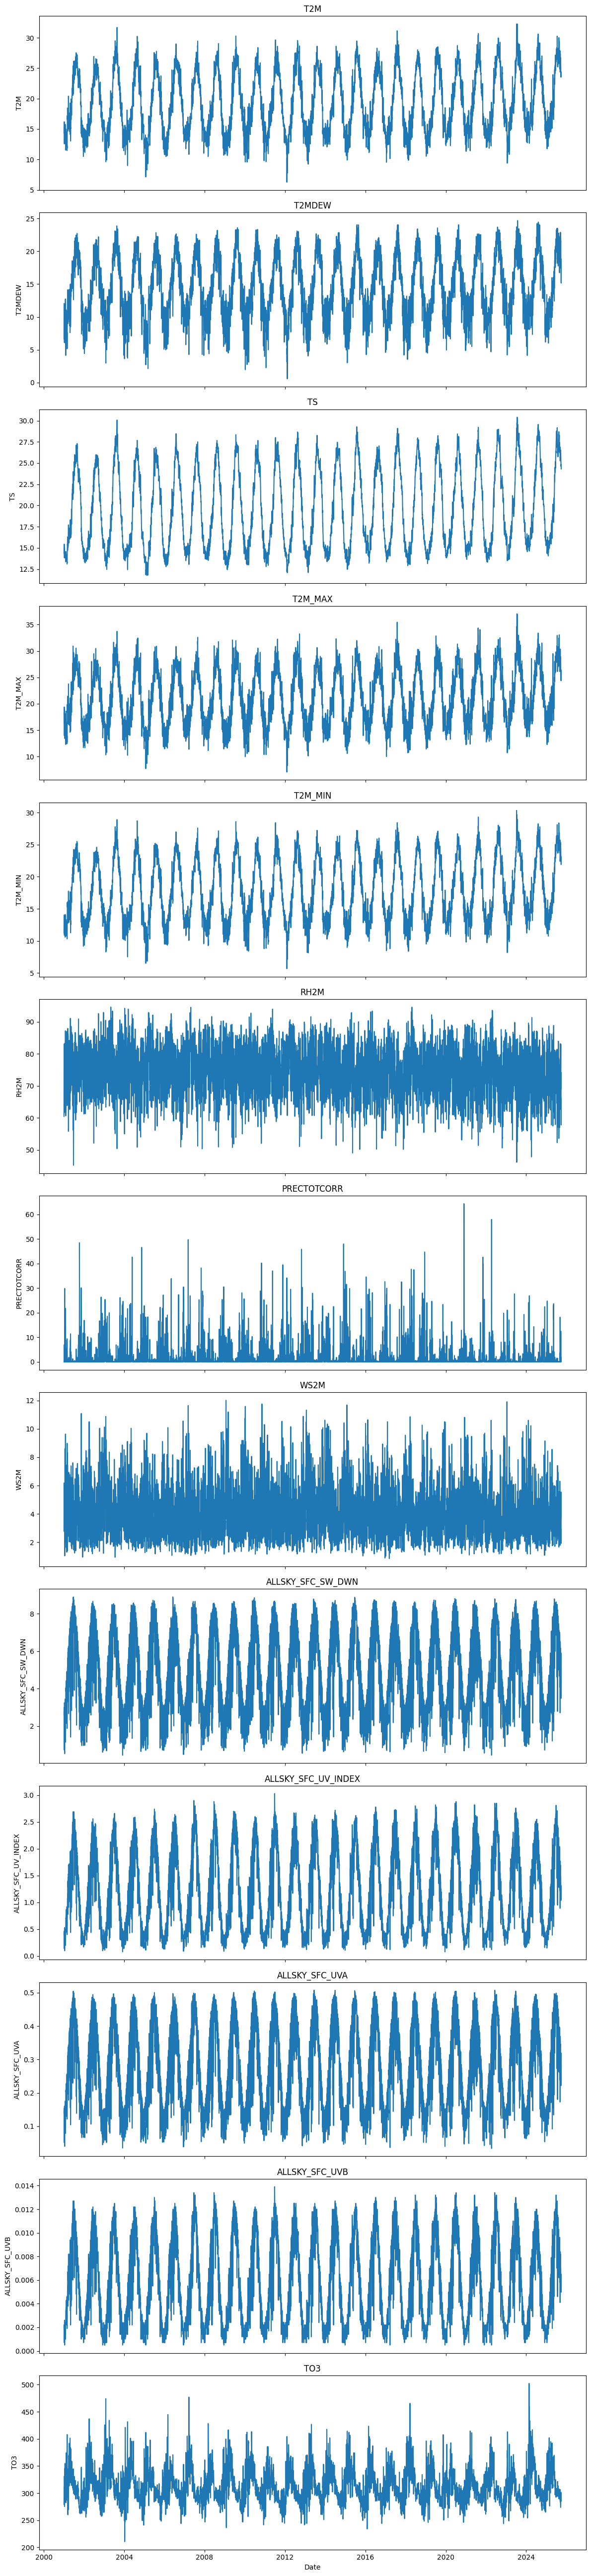

In [14]:
# Plot all remaining numeric columns over time
numeric_cols = algeria_df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4 * len(numeric_cols)), sharex=True)

for i, col in enumerate(numeric_cols):
    axes[i].plot(algeria_df['Date'], algeria_df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

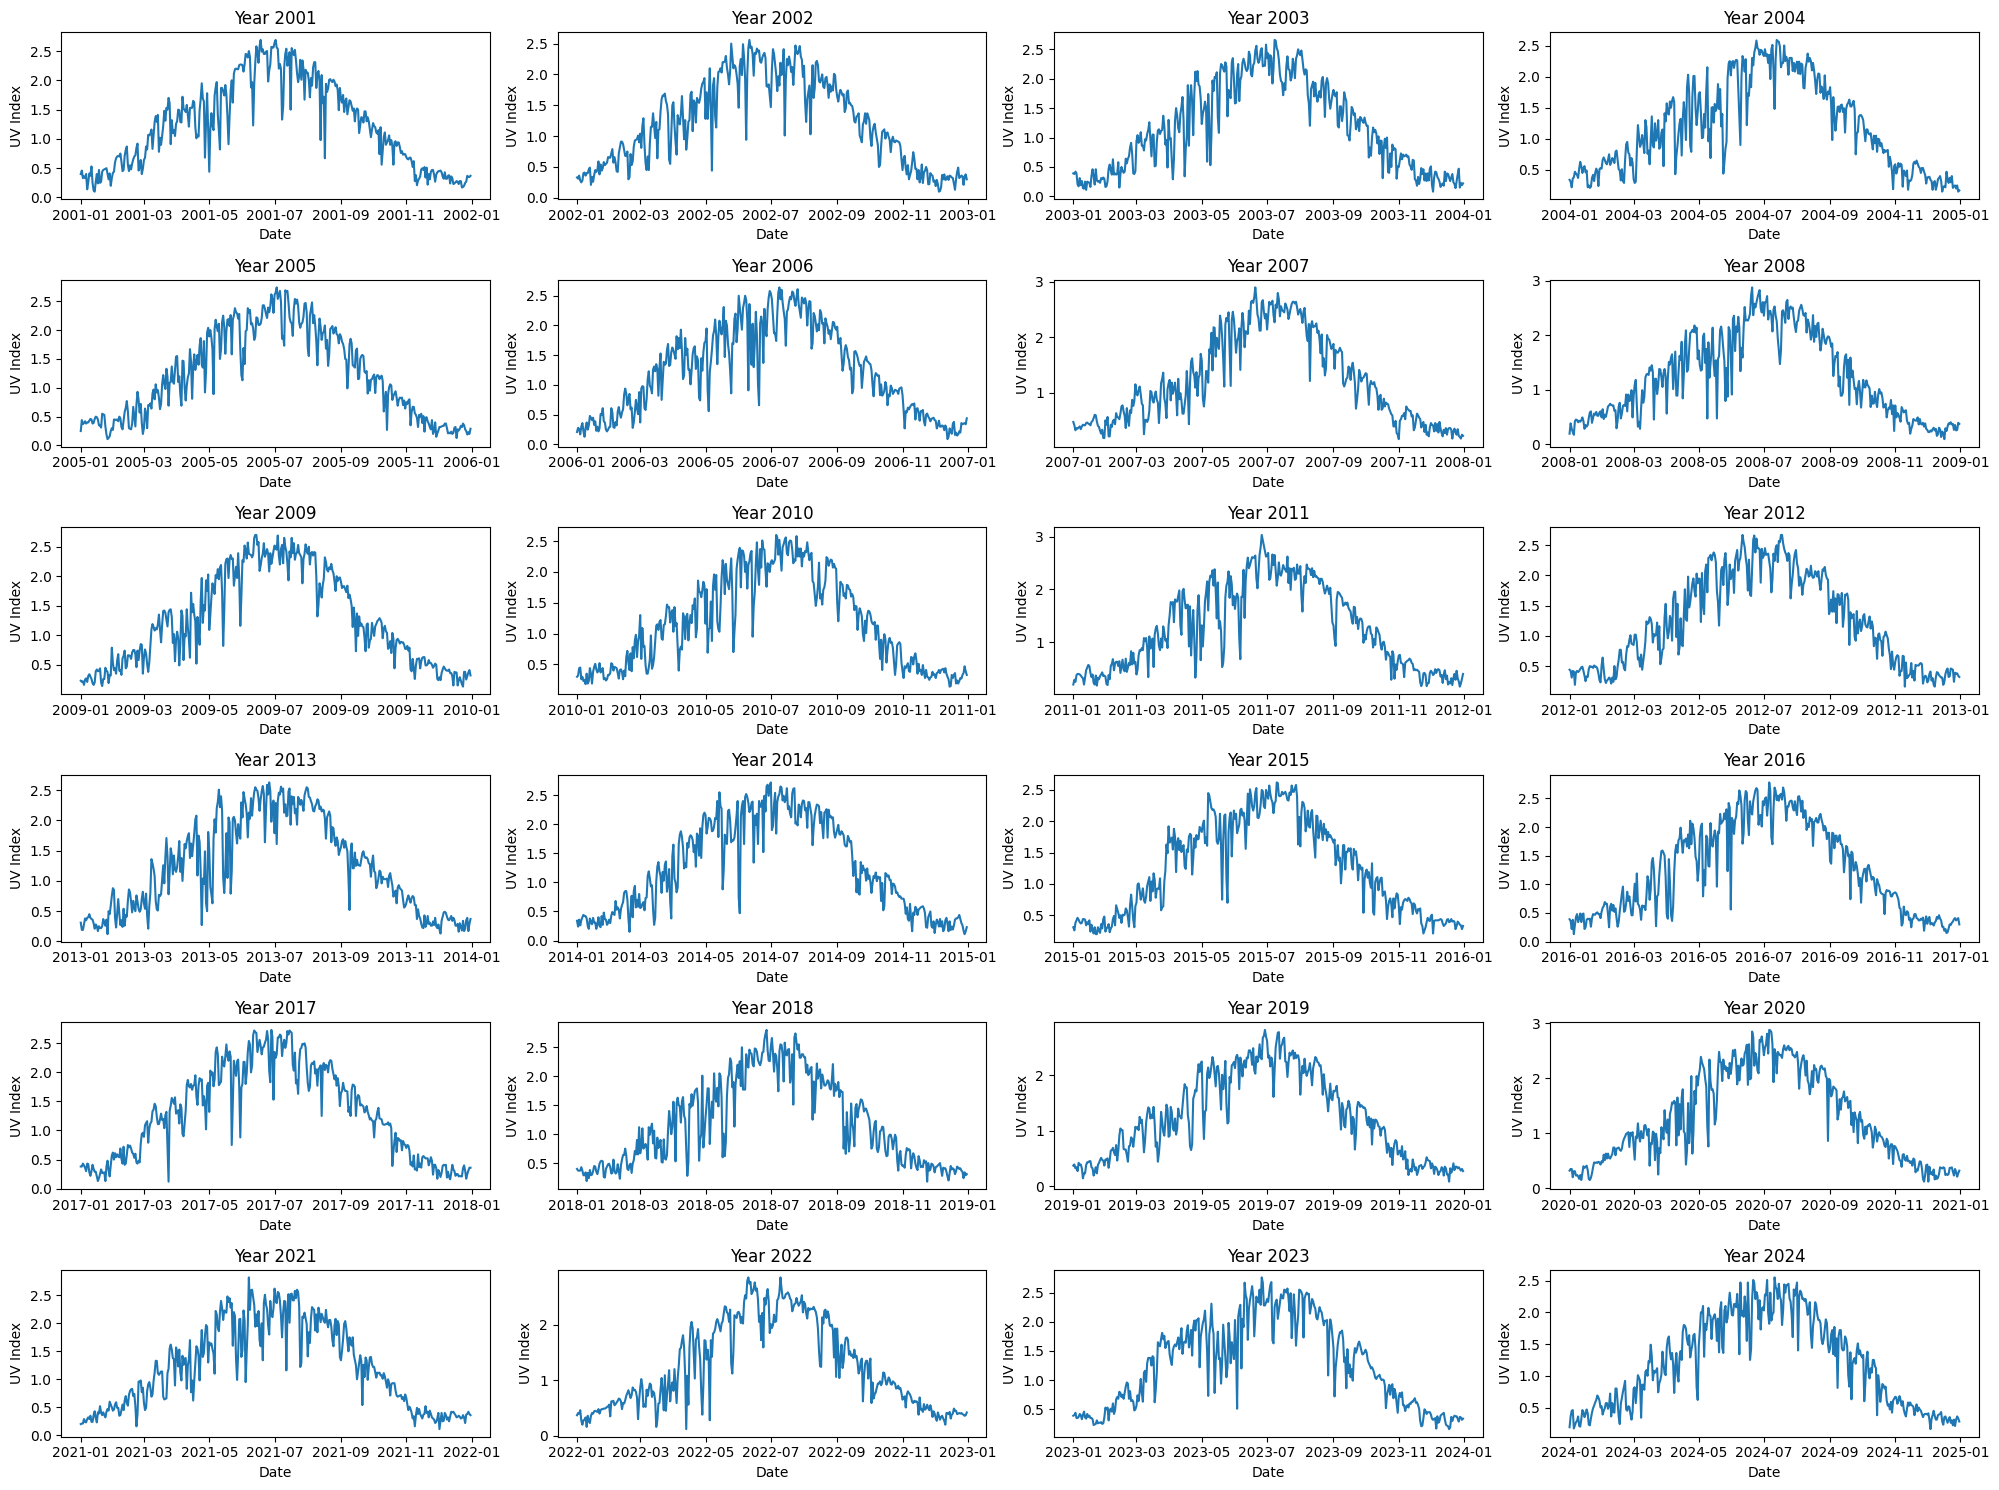

In [15]:
# Plot UV Index for each year from 2001 to 2024 in subplots
years = range(2001, 2025)  # 24 years
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, year in enumerate(years):
    year_data = algeria_df[algeria_df['Date'].dt.year == year]
    axes[i].plot(year_data['Date'], year_data['ALLSKY_SFC_UV_INDEX'])
    axes[i].set_title(f'Year {year}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('UV Index')

plt.tight_layout()
plt.show()

# Modelling

## Time Series Models

### Preparation

In [16]:
from ts import (
    MODELS, train_sarima, train_arima, train_ets, train_prophet, train_garch,
    train_naive, train_seasonal_naive, forecast_model, evaluate_forecast,
    get_default_params, PROPHET_AVAILABLE, GARCH_AVAILABLE
)

In [17]:
ts_df = algeria_df.set_index("Date")[["ALLSKY_SFC_UV_INDEX"]].copy().sort_index()

train_size = int(len(ts_df) * 0.8)
train_ts = ts_df.iloc[:train_size]
test_ts  = ts_df.iloc[train_size:]

train_series = train_ts["ALLSKY_SFC_UV_INDEX"]
y_true = test_ts["ALLSKY_SFC_UV_INDEX"].values
h = len(test_ts)

print(f"Train size: {len(train_ts)}, Test size: {len(test_ts)}")

ts_results = {}

def _store_result(name, model, forecast):
    metrics = evaluate_forecast(y_true, forecast)
    ts_results[name] = {
        "model": model,
        "forecast": forecast,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
    }
    print(f"{name} - RMSE: {metrics['RMSE']:.4f}, MAE: {metrics['MAE']:.4f}")

Train size: 7230, Test size: 1808


### Models

#### ARIMA

In [ ]:
try:
    # Use seasonal approach for UV data which has strong yearly patterns
    print("Training ARIMA with seasonal components for UV data...")
    arima = train_arima(train_series, auto=True, use_seasonal=True)
    print(f"Model type: {type(arima.model)}")
    if hasattr(arima.model, 'order'):
        print(f"ARIMA order: {arima.model.order}")
    if hasattr(arima.model, 'seasonal_order'):
        print(f"Seasonal order: {arima.model.seasonal_order}")
    arima_forecast = forecast_model(arima, h, "ARIMA", train_series)
    _store_result("ARIMA", arima, arima_forecast)
except Exception as e:
    print(f"ARIMA failed: {e}")
    # Fallback to simple ARIMA
    try:
        print("Falling back to simple auto ARIMA...")
        arima = train_arima(train_series, auto=True, use_seasonal=False)
        arima_forecast = forecast_model(arima, h, "ARIMA", train_series)
        _store_result("ARIMA", arima, arima_forecast)
    except Exception as e2:
        print(f"Fallback ARIMA also failed: {e2}")

Training ARIMA with seasonal components for UV data...


In [ ]:
# Reload the updated ts module
import importlib
import ts
importlib.reload(ts)
from ts import train_arima, forecast_model

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test_ts.index, y_true, label='Actual', color='blue', linewidth=1.5)
plt.plot(test_ts.index, arima_forecast.values, label='ARIMA Forecast', color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Date')
plt.ylabel('UV Index')
plt.title('ARIMA Forecast vs Actual UV Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### SARIMA

In [ ]:
try:
    sarima = train_sarima(train_series, order=(1,1,1), seasonal_order=(1,1,1,7))
    sarima_forecast = forecast_model(sarima, h, "SARIMA", train_series)
    _store_result("SARIMA", sarima, sarima_forecast)
except Exception as e:
    print(f"SARIMA failed: {e}")

#### ETS

In [ ]:
try:
    ets = train_ets(train_series, seasonal="add", seasonal_periods=7)
    ets_forecast = forecast_model(ets, h, "ETS", train_series)
    _store_result("ETS", ets, ets_forecast)
except Exception as e:
    print(f"ETS failed: {e}")

#### Prophet

In [ ]:
try:
    prophet_m = train_prophet(train_series)
    prophet_forecast = forecast_model(prophet_m, h, "PROPHET", train_series)
    _store_result("PROPHET", prophet_m, prophet_forecast)
except Exception as e:
    print(f"PROPHET failed: {e}")

#### GARCH

In [ ]:
try:
    garch = train_garch(train_series)
    garch_forecast = forecast_model(garch, h, "GARCH", train_series)
    _store_result("GARCH", garch, garch_forecast)
except Exception as e:
    print(f"GARCH failed: {e}")


#### Naive

In [ ]:
try:
    naive = train_naive(train_series)
    naive_forecast = forecast_model(naive, h, "NAIVE", train_series)
    _store_result("NAIVE", naive, naive_forecast)
except Exception as e:
    print(f"NAIVE failed: {e}")


#### Seasonal Naive

In [ ]:
try:
    snaive = train_seasonal_naive(train_series, season=7)
    snaive_forecast = forecast_model(snaive, h, "SEASONAL_NAIVE", train_series)
    _store_result("SEASONAL_NAIVE", snaive, snaive_forecast)
except Exception as e:
    print(f"SEASONAL_NAIVE failed: {e}")

#### Summary

In [ ]:
ts_metrics_df = (
    pd.DataFrame(
        [{"Model": k, "RMSE": v["RMSE"], "MAE": v["MAE"]} for k, v in ts_results.items()]
    )
    .sort_values("RMSE")
)

print("\n=== Time Series Models Summary ===")
print(ts_metrics_df.to_string(index=False))

## Boosters